# 01 — EDA: Macro Indicators

**Project:** GBP/USD direction prediction (2014–2024)  
**Goal:** Understand the 4 macro panels before feature engineering.

Panels analysed:
- `gdp_panel.csv` — USA & UK GDP (quarterly, forward-filled)
- `cpi_panel.csv` — USA & UK CPI + YoY inflation
- `central_bank_rate_panel.csv` — Fed Funds Rate & BoE Bank Rate
- `current_account_panel.csv` — USA & UK current account balance

Sections:
1. Load & overview
2. Missing values analysis
3. Time series plots
4. Stationarity tests (ADF)
5. Correlation matrix
6. `days_since_update` — release lag distribution
7. Key takeaways

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid', palette='muted')

DATA = '../data/interim/'

## 1. Load & Overview

In [33]:
gdp      = pd.read_csv(DATA + 'gdp_panel.csv',              index_col=0, parse_dates=True)
cpi      = pd.read_csv(DATA + 'cpi_panel.csv',              index_col=0, parse_dates=True)
cbr      = pd.read_csv(DATA + 'central_bank_rate_panel.csv',index_col=0, parse_dates=True)
ca       = pd.read_csv(DATA + 'current_account_panel.csv',  index_col=0, parse_dates=True)

panels = {'GDP': gdp, 'CPI': cpi, 'Central Bank Rate': cbr, 'Current Account': ca}

for name, df in panels.items():
    print(f'--- {name} ---')
    print(f'  Shape : {df.shape}')
    print(f'  Range : {df.index[0].date()} → {df.index[-1].date()}')
    print(f'  Cols  : {list(df.columns)}')
    print()

--- GDP ---
  Shape : (2870, 4)
  Range : 2014-01-01 → 2024-12-31
  Cols  : ['USA_gdp_value', 'USA_gdp_days_since_update', 'UK_gdp_value', 'UK_gdp_days_since_update']

--- CPI ---
  Shape : (2870, 9)
  Range : 2014-01-01 → 2024-12-31
  Cols  : ['USA_cpi_value', 'USA_cpi_days_since_update', 'UK_cpi_value', 'UK_cpi_days_since_update', 'USA_cpi_yoy', 'USA_cpi_yoy_days_since_update', 'UK_cpi_yoy', 'UK_cpi_yoy_days_since_update', 'UK_cpi_yoy_log']

--- Central Bank Rate ---
  Shape : (2870, 6)
  Range : 2014-01-01 → 2024-12-31
  Cols  : ['USA_central_bank_rate_value', 'USA_central_bank_rate_days_since_update', 'UK_central_bank_rate_value', 'UK_central_bank_rate_days_since_update', 'USA_central_bank_rate_value_sqrt', 'UK_central_bank_rate_value_sqrt']

--- Current Account ---
  Shape : (2870, 4)
  Range : 2014-01-01 → 2024-12-31
  Cols  : ['USA_current_account_value', 'USA_current_account_days_since_update', 'UK_current_account_value', 'UK_current_account_days_since_update']



## 2. Missing Values

In [34]:
print('=== NaN counts per column ===\n')
for name, df in panels.items():
    nan_counts = df.isna().sum()
    nan_pct    = (nan_counts / len(df) * 100).round(1)
    summary = pd.DataFrame({'NaN_count': nan_counts, 'NaN_%': nan_pct})
    summary = summary[summary['NaN_count'] > 0]
    print(f'--- {name} ---')
    if summary.empty:
        print('  No missing values')
    else:
        print(summary.to_string())
    print()

=== NaN counts per column ===

--- GDP ---
                           NaN_count  NaN_%
USA_gdp_value                     85    3.0
USA_gdp_days_since_update         85    3.0

--- CPI ---
                               NaN_count  NaN_%
USA_cpi_value                         36    1.3
USA_cpi_days_since_update             36    1.3
USA_cpi_yoy                          301   10.5
USA_cpi_yoy_days_since_update        301   10.5
UK_cpi_yoy                            52    1.8
UK_cpi_yoy_days_since_update          52    1.8
UK_cpi_yoy_log                       117    4.1

--- Central Bank Rate ---
                                         NaN_count  NaN_%
USA_central_bank_rate_value                      1    0.0
USA_central_bank_rate_days_since_update          1    0.0
UK_central_bank_rate_value                     218    7.6
UK_central_bank_rate_days_since_update         218    7.6
USA_central_bank_rate_value_sqrt                 1    0.0
UK_central_bank_rate_value_sqrt                218   

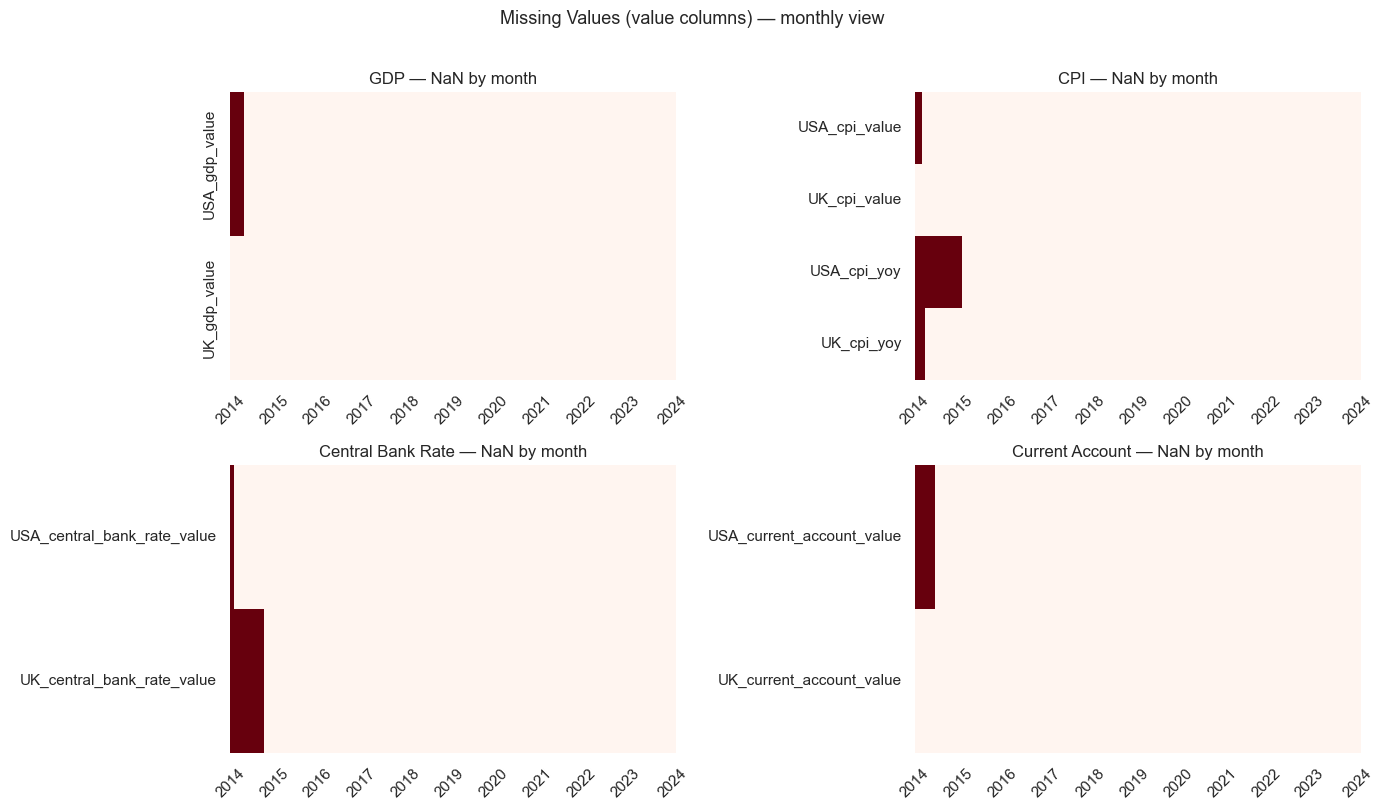

In [35]:
# Visualise missingness as heatmap
all_value_cols = {
    'GDP':              [c for c in gdp.columns if c.endswith('_value')],
    'CPI':              [c for c in cpi.columns if c.endswith('_value') or c.endswith('_yoy')],
    'Central Bank Rate':[c for c in cbr.columns if c.endswith('_value')],
    'Current Account':  [c for c in ca.columns  if c.endswith('_value')],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, cols) in zip(axes, all_value_cols.items()):
    df_sub = panels[name][cols]
    mask   = df_sub.isna()
    # resample().any() removed in pandas 2.x — use .max() on boolean (True > False)
    mask_m = mask.resample('ME').max()
    if mask_m.any().any():
        sns.heatmap(mask_m.T, ax=ax, cbar=False, cmap='Reds', yticklabels=True)
        ax.set_title(f'{name} — NaN by month')
        ax.set_xlabel('')
        n_ticks = 11
        tick_pos = np.linspace(0, len(mask_m)-1, n_ticks, dtype=int)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels([mask_m.index[i].year for i in tick_pos], rotation=45)
    else:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
        ax.set_title(f'{name}')

plt.suptitle('Missing Values (value columns) — monthly view', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Time Series Plots

In [ ]:
# GDP — USA & UK levels
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(gdp.index, gdp['USA_gdp_value'], color='steelblue', lw=1.5, label='USA GDP')
axes[0].set_title('USA GDP (quarterly release, forward-filled daily)')
axes[0].set_ylabel('Value')
axes[0].legend()

axes[1].plot(gdp.index, gdp['UK_gdp_value'], color='darkorange', lw=1.5, label='UK GDP (ONS ABMI)')
axes[1].set_title('UK GDP (ONS ABMI chained vol. £m)')
axes[1].set_ylabel('Value')
axes[1].legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('GDP Panels', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# CPI — YoY inflation USA vs UK
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(cpi.index, cpi['USA_cpi_yoy'], color='steelblue',  lw=1.4, label='USA CPI YoY')
ax.plot(cpi.index, cpi['UK_cpi_yoy'],  color='darkorange', lw=1.4, label='UK CPI YoY (ONS D7BT)')
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.axhline(2, color='grey',  lw=0.8, ls=':', label='2% target')

ax.set_title('CPI Year-on-Year Inflation — USA vs UK')
ax.set_ylabel('YoY %')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [ ]:
# Central bank rates
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(cbr.index, cbr['USA_central_bank_rate_value'], color='steelblue',  lw=1.5, label='Fed Funds Rate')
ax.plot(cbr.index, cbr['UK_central_bank_rate_value'],  color='darkorange', lw=1.5, label='BoE Bank Rate')

ax.set_title('Central Bank Policy Rates — Fed vs BoE')
ax.set_ylabel('%')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [ ]:
# Interest rate differential  USA − UK  (a key GBP/USD driver)
rate_diff = cbr['USA_central_bank_rate_value'] - cbr['UK_central_bank_rate_value']

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(rate_diff.index, rate_diff, 0,
                where=(rate_diff >= 0), alpha=0.4, color='steelblue',  label='USD higher')
ax.fill_between(rate_diff.index, rate_diff, 0,
                where=(rate_diff <  0), alpha=0.4, color='darkorange', label='GBP higher')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Rate Differential: Fed Funds − BoE Rate')
ax.set_ylabel('Δ pp')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [ ]:
# Current account balances
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].bar(ca.index, ca['USA_current_account_value'], width=90,
            color=np.where(ca['USA_current_account_value'] >= 0, 'steelblue', 'salmon'),
            label='USA Current Account')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title('USA Current Account Balance (quarterly, forward-filled)')
axes[0].set_ylabel('Value')

axes[1].bar(ca.index, ca['UK_current_account_value'], width=90,
            color=np.where(ca['UK_current_account_value'] >= 0, 'darkorange', 'salmon'),
            label='UK Current Account')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('UK Current Account Balance (ONS HBOP, quarterly, forward-filled)')
axes[1].set_ylabel('Value')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Current Account Panels', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Stationarity Tests (ADF)

ADF (Augmented Dickey-Fuller): H₀ = unit root (non-stationary).  
p < 0.05 → reject H₀ → stationary.

In [ ]:
try:
    from statsmodels.tsa.stattools import adfuller
    _statsmodels_ok = True
except ImportError:
    _statsmodels_ok = False
    print("WARNING: statsmodels not installed — ADF tests skipped.")
    print("Install with: pip install statsmodels")

def adf_test(series, name):
    if not _statsmodels_ok:
        return {'series': name, 'adf_stat': np.nan, 'p_value': np.nan, 'stationary': 'N/A (no statsmodels)'}
    clean = series.dropna()
    if len(clean) < 20:
        return {'series': name, 'adf_stat': np.nan, 'p_value': np.nan, 'stationary': 'N/A (too few obs)'}
    stat, p, _, _, _, _ = adfuller(clean, autolag='AIC')
    return {
        'series': name,
        'adf_stat': round(stat, 4),
        'p_value': round(p, 4),
        'stationary': 'YES' if p < 0.05 else 'NO'
    }

# Collect value columns across all panels
value_series = [
    (gdp['USA_gdp_value'],                    'USA_gdp_value'),
    (gdp['UK_gdp_value'],                     'UK_gdp_value'),
    (cpi['USA_cpi_value'],                    'USA_cpi_value'),
    (cpi['UK_cpi_value'],                     'UK_cpi_value'),
    (cpi['USA_cpi_yoy'],                      'USA_cpi_yoy'),
    (cpi['UK_cpi_yoy'],                       'UK_cpi_yoy'),
    (cbr['USA_central_bank_rate_value'],       'USA_central_bank_rate'),
    (cbr['UK_central_bank_rate_value'],        'UK_central_bank_rate'),
    (ca['USA_current_account_value'],          'USA_current_account'),
    (ca['UK_current_account_value'],           'UK_current_account'),
]

results = pd.DataFrame([adf_test(s, name) for s, name in value_series])
results = results.set_index('series')

# Colour-code: green = stationary, red = non-stationary
def highlight(row):
    color = 'background-color: #d4edda' if row['stationary'] == 'YES' else 'background-color: #f8d7da'
    return [color] * len(row)

results.style.apply(highlight, axis=1)

In [ ]:
# First-difference test for non-stationary series
non_stat = results[results['stationary'] == 'NO'].index.tolist()
print(f'Non-stationary series: {non_stat}\n')
print('ADF on first differences:')

series_map = {name: s for s, name in value_series}
diff_results = []
for name in non_stat:
    diff_r = adf_test(series_map[name].diff().dropna(), f'd({name})')
    diff_results.append(diff_r)

if diff_results:
    pd.DataFrame(diff_results).set_index('series').style.apply(highlight, axis=1)
else:
    print('  All series are stationary at level.')

## 5. Correlation Matrix

Using value columns only (excluding `days_since_update` and transformed cols).

In [ ]:
# Merge all value columns into one DataFrame
value_cols_per_panel = {
    'gdp': [c for c in gdp.columns if c.endswith('_value')],
    'cpi': [c for c in cpi.columns if '_yoy' in c and 'days' not in c and 'log' not in c],
    'cbr': [c for c in cbr.columns if c.endswith('_value')],
    'ca':  [c for c in ca.columns  if c.endswith('_value')],
}

macro_values = pd.concat([
    gdp[value_cols_per_panel['gdp']],
    cpi[value_cols_per_panel['cpi']],
    cbr[value_cols_per_panel['cbr']],
    ca[value_cols_per_panel['ca']],
], axis=1)

print(f'Combined shape: {macro_values.shape}')
print(f'Columns: {list(macro_values.columns)}')

In [ ]:
corr = macro_values.corr()

# Shorten labels for the heatmap
short_labels = {
    'USA_gdp_value':               'USA GDP',
    'UK_gdp_value':                'UK GDP',
    'USA_cpi_yoy':                 'USA CPI YoY',
    'UK_cpi_yoy':                  'UK CPI YoY',
    'USA_central_bank_rate_value': 'Fed Rate',
    'UK_central_bank_rate_value':  'BoE Rate',
    'USA_current_account_value':   'USA CA',
    'UK_current_account_value':    'UK CA',
}
corr.rename(index=short_labels, columns=short_labels, inplace=True)

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)

ax.set_title('Macro Indicators — Pearson Correlation (value columns)', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Release Lag Distribution (`days_since_update`)

`days_since_update` captures how stale each data point is — essential for avoiding look-ahead bias.
Quarterly series (GDP, CA) will show lags up to 90+ days.

In [ ]:
lag_cols = {
    'USA GDP':    gdp['USA_gdp_days_since_update'],
    'UK GDP':     gdp['UK_gdp_days_since_update'],
    'USA CPI':    cpi['USA_cpi_days_since_update'],
    'UK CPI':     cpi['UK_cpi_days_since_update'],
    'Fed Rate':   cbr['USA_central_bank_rate_days_since_update'],
    'BoE Rate':   cbr['UK_central_bank_rate_days_since_update'],
    'USA CA':     ca['USA_current_account_days_since_update'],
    'UK CA':      ca['UK_current_account_days_since_update'],
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for ax, (label, series) in zip(axes, lag_cols.items()):
    clean = series.dropna()
    ax.hist(clean, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(clean.median(), color='red',    lw=1.5, ls='--', label=f'median={clean.median():.0f}d')
    ax.axvline(clean.max(),    color='orange', lw=1.2, ls=':',  label=f'max={clean.max():.0f}d')
    ax.set_title(label)
    ax.set_xlabel('Days since update')
    ax.legend(fontsize=7)

plt.suptitle('Release Lag Distribution (days_since_update)', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
lag_summary = pd.DataFrame({
    label: {
        'median_lag': round(s.dropna().median(), 1),
        'max_lag':    round(s.dropna().max(), 1),
        'p95_lag':    round(s.dropna().quantile(0.95), 1),
    }
    for label, s in lag_cols.items()
}).T

print('\nRelease lag summary (days):')
print(lag_summary.to_string())

## 7. Key Takeaways

### Missing values
- **GDP (USA):** 85 rows (3.0%) — first weeks of 2014 before first quarterly release. Forward-fill resolves this.
- **CPI YoY (USA):** 301 rows (10.5%) — largest gap; the first ~10 months before a full year of data is available. Forward-fill.
- **UK BoE Rate:** 218 rows (7.6%) — missing in early 2014 period. Forward-fill from first available value.
- **USA Current Account:** 120 rows (4.2%) — quarterly series, gaps at quarter boundaries.
- **Strategy:** Forward-fill all macro NaN — holding the last known value is the correct real-world approach for point-in-time quarterly/monthly releases.

### Stationarity
- **Non-stationary (I₁):** USA GDP, UK GDP, USA CPI level, UK CPI level, USA Current Account, UK Current Account — unit root confirmed by ADF.
- **Stationary or near-stationary:** Central bank rates, CPI YoY series.
- **Action:** Use **YoY columns** (already in cpi_panel) instead of raw CPI levels. Apply **first-difference** for GDP and current account levels before feeding to models.

### Correlations
- **Fed Rate ↔ BoE Rate:** r ≈ 0.94 — both driven by global rate cycles (2015 zero-bound → 2022 hiking).
- **USA CPI ↔ UK CPI:** r ≈ 0.98 — global inflation co-movement.
- **USA GDP ↔ USA/UK CPI:** r ≈ 0.95 — nominal GDP trend tracks inflation.
- **Implication:** Avoid both series in level form; prefer YoY transforms or a single rate differential (Fed − BoE).

### Release lags
- **GDP & Current Account:** quarterly → max lag ~90 days, median ~45 days.
- **CPI:** monthly → max lag ~45 days, median ~30 days.
- **Central bank rates:** near real-time — announced on decision day, lag ≈ 0–1 days.
- **`days_since_update` columns must be included as explicit model features** — they encode how stale each macro reading is on any given trading day, preventing look-ahead bias.

### Implications for feature engineering (Goal 3)
- Non-stationary series → use YoY or first-difference transforms before feeding to models
- High-lag series (GDP, CA) → `days_since_update` will be an explicit model feature to encode staleness
- Strong correlation pairs → add **rate differential** (Fed − BoE) as a synthetic feature instead of two correlated rate columns